# MUSIC Imaging — SMPL Human Body

**Pipeline:**
1. Scene places an SMPL body mesh with lighting
2. Tracer ray-traces the scene → reflection points + intensities
3. Radar (20×20 UPA, Dirichlet solver) generates a full MIMO frame
4. MUSIC algorithm produces high-resolution 2D angle image per range bin

**Requires:** smplpytorch, mitsuba (cuda_ad_rgb variant)

In [1]:
import sys, pathlib
repo_root = pathlib.Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import numpy as np
import torch
import matplotlib.pyplot as plt
from witwin.radar import Material, Radar, Scene, Tracer
from witwin.radar.sigproc import MUSICImager

MODEL_ROOT = repo_root / 'models' / 'smpl_models'


c:\Users\Asixa\miniconda3\envs\witwin2\Lib\site-packages\slangtorch\slangtorch.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
jitc_llvm_init(): LLVM API initialization failed ..


## 1. Radar Config — 20×20 UPA

In [2]:
fc = 77e9

config = {
    "num_tx": 20, "num_rx": 20,
    "fc": fc,
    "slope": 60.012,
    "adc_samples": 256,
    "adc_start_time": 6,
    "sample_rate": 4400,
    "idle_time": 7,
    "ramp_end_time": 65,
    "chirp_per_frame": 8,
    "frame_per_second": 10,
    "num_doppler_bins": 8,
    "num_range_bins": 256,
    "num_angle_bins": 64,
    "power": 15,
    "tx_loc": [[i, 0, 0] for i in range(20)],
    "rx_loc": [[20, -i, 0] for i in range(20)],
}
radar = Radar(config)

c:\Users\Asixa\miniconda3\envs\witwin2\Lib\site-packages\setuptools\_distutils\_msvccompiler.py:12: UserWarning: _get_vc_env is private; find an alternative (pypa/distutils#340)
  warnings.warn(


## 2. Scene: SMPL Body in Front of Radar

In [3]:
scene = Scene()

print("Adding SMPL body to scene...")
pose = np.zeros(72)        # T-pose
shape = np.zeros(10)       # average body shape
scene.add_smpl(name="human", pose=pose, shape=shape, position=[0, 0, -3], gender='male', model_root=str(MODEL_ROOT), material=Material(eps_r=3.0))

tracer = Tracer(scene, radar, resolution=128)

Adding SMPL body to scene...


## 3. Ray Trace

In [4]:
points, intensities = tracer.trace()
print(f"{points.shape[0]} reflection points")
print(f"Z range: {points[:, 2].min():.2f} ~ {points[:, 2].max():.2f} m")

806 reflection points
Z range: -3.08 ~ -2.85 m


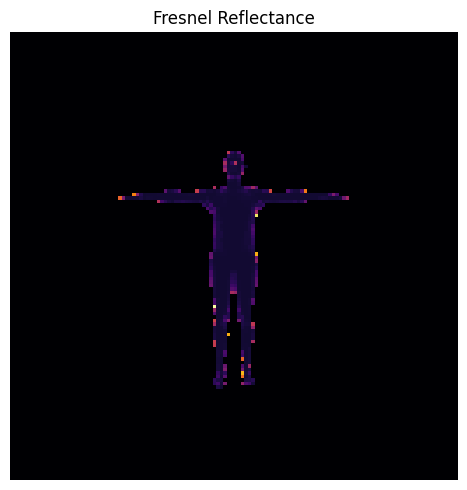

In [5]:
image = tracer.render_image()
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(image.cpu().numpy(), cmap='inferno', origin='upper')
ax.set_title('Fresnel Reflectance')
ax.axis('off')
plt.tight_layout()

## 4. Radar MIMO Frame (20×20)

In [6]:
velocity = torch.tensor([0, 0, 0.01], device='cuda')

def location_function(t):
    return intensities * 10, points + velocity * t

frame = radar.mimo(location_function, t0=0)
noise_scale = 1e-6
g = torch.Generator(device='cuda')
g.manual_seed(0)
noise = torch.complex(
    torch.randn(frame.shape, device='cuda', generator=g),
    torch.randn(frame.shape, device='cuda', generator=g),
).to(frame.dtype) * noise_scale
frame = frame + noise
print(f"Frame shape: {frame.shape}  (TX, RX, chirps, ADC)")
print(f"Added complex noise regularization: {noise_scale}")

Frame shape: torch.Size([20, 20, 8, 256])  (TX, RX, chirps, ADC)
Added complex noise regularization: 1e-06


## 5. MUSIC Imaging

In [7]:
imager = MUSICImager(num_tx=20, num_rx=20, num_signals=7,
                     spatial_smooth=3, num_pixels=128, num_chirps=8)

image3D = imager.radar_image(frame)
print(f"Image shape: {image3D.shape}  (H, W, range_bins)")

# Sum across range bins for a 2D angle image
image2D = image3D.sum(dim=2)

Image shape: torch.Size([128, 128, 5])  (H, W, range_bins)


## 6. Visualization

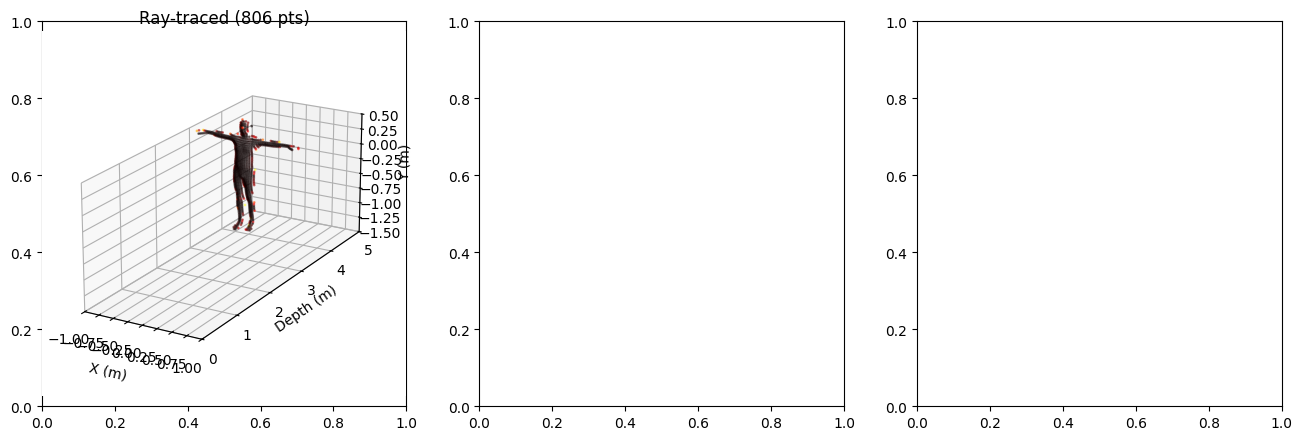

In [8]:
ranges = radar.ranges.cpu().numpy()
velocities = radar.velocities.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Ray-traced reflection points
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
pts = points.cpu().numpy()
ax1.scatter(pts[:, 0], -pts[:, 2], pts[:, 1],
            c=intensities.cpu().numpy(), cmap='hot', s=1, alpha=0.5)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_zlabel('Y (m)')
ax1.set_title(f'Ray-traced ({pts.shape[0]} pts)')
ax1.set_xlim(-1, 1)
ax1.set_ylim(0, 5)
ax1.set_zlim(-1.5, 0.5)
ax1.set_box_aspect([1, 2.5, 1])
ax1.view_init(elev=20, azim=-60)

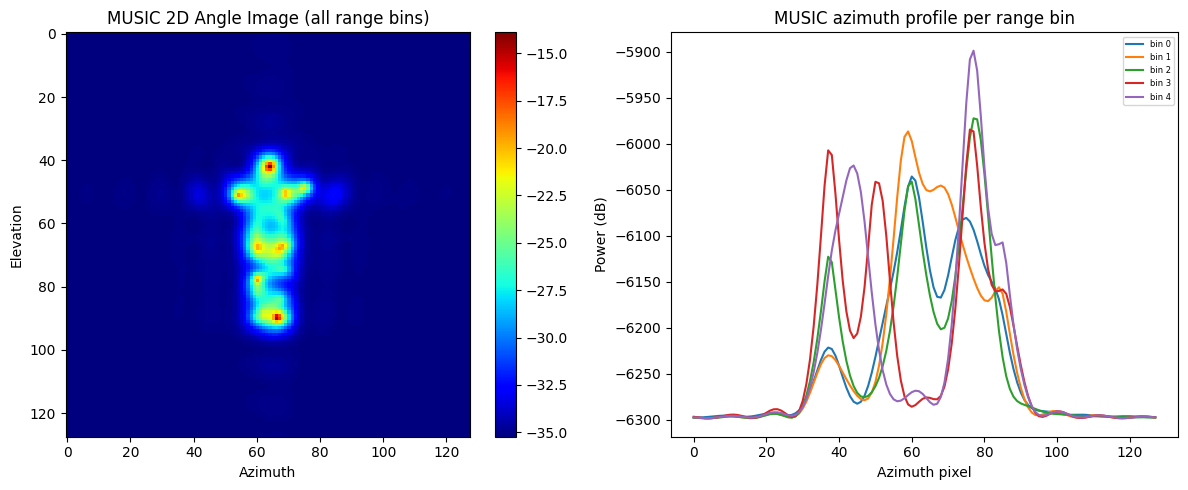

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (b) MUSIC 2D image (sum over range)
music_db = 20 * torch.log10(torch.abs(image2D) + 1e-6)
im = axes[0].imshow(np.rot90(music_db.detach().cpu().numpy(), 1), cmap='jet')
axes[0].set_title('MUSIC 2D Angle Image (all range bins)')
axes[0].set_xlabel('Azimuth')
axes[0].set_ylabel('Elevation')
plt.colorbar(im, ax=axes[0])

# (c) MUSIC per range bin (azimuth profile)
for i in range(image3D.shape[2]):
    slice_db = 20 * torch.log10(torch.abs(image3D[:, :, i]) + 1e-6)
    axes[1].plot(slice_db.sum(dim=0).detach().cpu().numpy(), label=f'bin {i}')
axes[1].set_title('MUSIC azimuth profile per range bin')
axes[1].set_xlabel('Azimuth pixel')
axes[1].set_ylabel('Power (dB)')
axes[1].legend(fontsize=6)

plt.tight_layout()

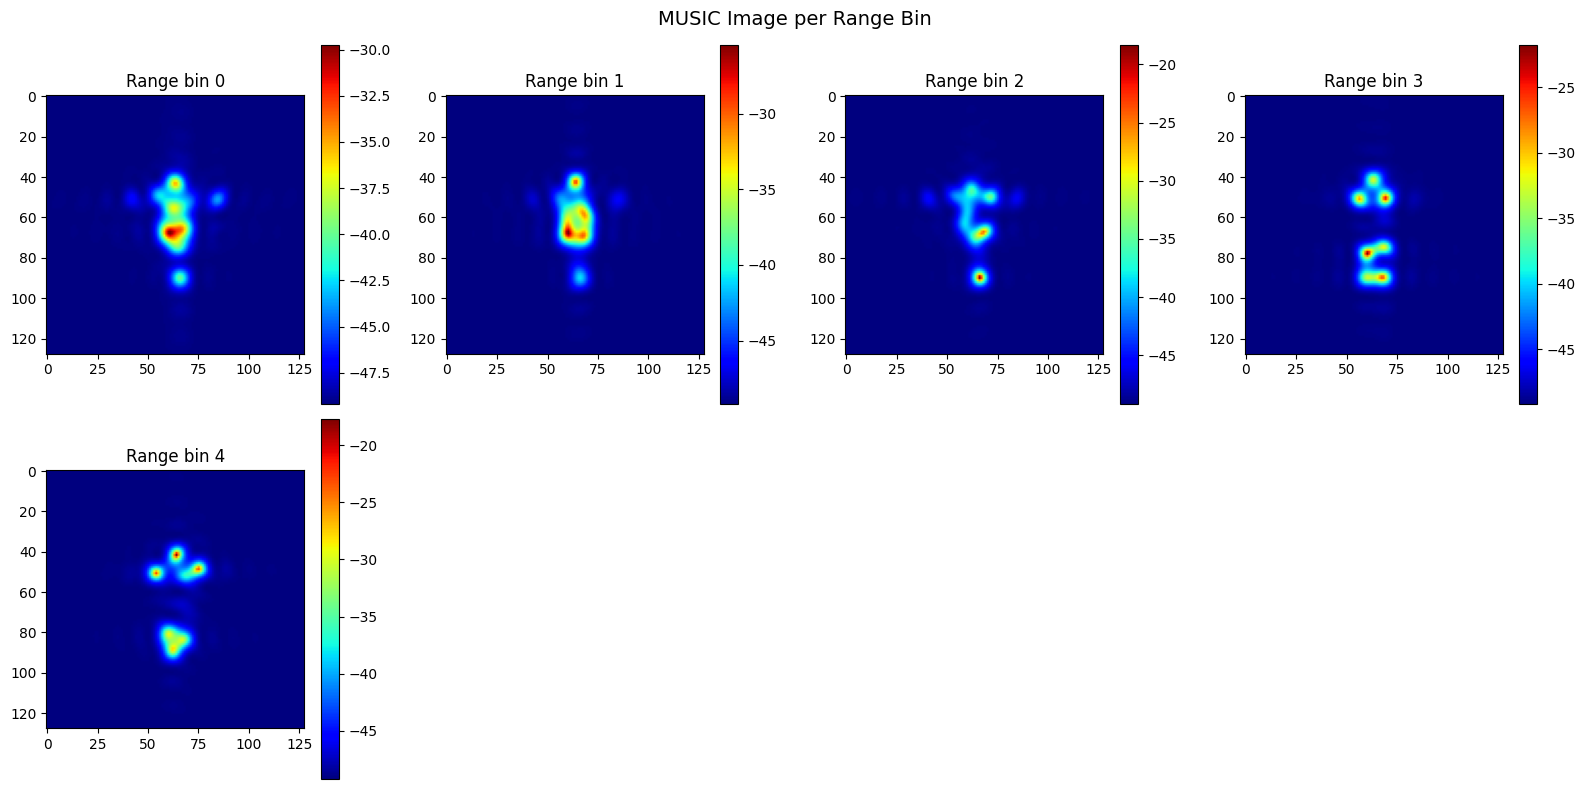

In [10]:
# Per-range-bin MUSIC images
num_bins = image3D.shape[2]
cols = min(num_bins, 4)
rows = (num_bins + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
if num_bins == 1:
    axes = np.array([[axes]])
axes = np.atleast_2d(axes)

for i in range(num_bins):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    slice_db = 20 * torch.log10(torch.abs(image3D[:, :, i]) + 1e-6)
    im = ax.imshow(np.rot90(slice_db.detach().cpu().numpy(), 1), cmap='jet')
    ax.set_title(f'Range bin {i}')
    plt.colorbar(im, ax=ax)

# Hide unused axes
for i in range(num_bins, rows * cols):
    r, c = divmod(i, cols)
    axes[r, c].axis('off')

plt.suptitle('MUSIC Image per Range Bin', fontsize=14)
plt.tight_layout()